# G2++ Model

<div style="background-color: #d5ffcd; padding: 10px; border-left: 4px solid #39ff07;">
⚠️ <b>Notes:</b> 
</div>

Done:
1. Montecarlo simulation
2. Bond prices / curves simulations

Ongoing:
1. Caps / Swaptions, pricing simulation and analytical, calibration
2. Get data (swaption, caps, floors prices, Bloomberg)

To Do:
1. Clean document (verify coherent use of variables and notations, verify formulas)
2. Binomial / Trinomial trees
3. Deep hedging framework

Questions:

- Use swaptions data at a date x to calibrate model, then observe daily hedging against actual swap price?, hedge what sort of derivatives
- How do you use G2++ model for swaps, since G2++ models bond prices (do you account for swap spread)

Objectives:

"Does deep hedging outperform standard hedging because the market is complex, or just because the simulation method favors it?"

- Use different simulation proceedures (Monte Carlo, Trinomial Tree, Finite Difference, etc.)

<div style="background-color: #d5ffcd; padding: 10px; border-left: 4px solid #39ff07;">
⚠️ <b>Notes:</b> 
</div>

<hr style="border: 0.5px solid lightgray;">

## Model Definition

The **G2++ model** is a two-factor Gaussian short-rate model. The short rate $r(t)$ is defined as:

$$
r(t) = x(t) + y(t) + \varphi(t), \quad r(0) = \varphi(0)
$$

where the two factors follow mean-reverting (Ornstein–Uhlenbeck) processes:

$$
dx(t) = -ax(t)\,dt + \sigma\,dW_1(t), \quad x(0) = 0
$$

$$
dy(t) = -by(t)\,dt + \eta\,dW_2(t), \quad y(0) = 0
$$

and $dW_1(t)\,dW_2(t) = \rho\,dt$.

## Parameters

| Parameter | Description |
|-----------|-------------|
| $a$ | Mean-reversion speed of factor $x$ |
| $b$ | Mean-reversion speed of factor $y$ |
| $\sigma$ | Volatility of factor $x$ |
| $\eta$ | Volatility of factor $y$ |
| $\rho$ | Correlation between $W_1$ and $W_2$ |
| $\varphi(t)$ | Deterministic shift fitted to the initial yield curve |


## Model Assumptions

1. Two-factor Gaussian model
    - The short rate is driven by 2 sources or randomness, making it more flexible versus One-factor models. $x(t)$ represent shorter term rates while $y(t)$ represents longer terms
2. Normally distributed rates
    - $x(t)$ and $y(t)$ are Gaussian. This implies possibility of negative rates
3. Mean reversion
    - Both $x(t)$ and $y(t)$ are mean reverting to zero. Generally, a >> b such that mean reversion in the short term is greater than in the long term
4. Constant parameters 
    - $a$, $b$, $\sigma$, $\eta$ and $\rho$ are constant over time
5. Perfect fit to initial yield or rates curve
    - $\varphi (t)$ is a deterministic function chosen such that the model fits the initial curve. Since $x(t)$ and $y(t)$ are both stochastic and mean reverting to zero, $\mathbb{E}[r(t) \mid \mathcal{F}_0] = \varphi (t)$
6. Correlation between short term and long term rates
    - The two Brownian motions are correlated through $dW_1(t)dW_2(t) = \rho dt$
7. No jumps
    - Rates move continuously, no sudden jumps
8. Risk-neutral measure
    - Model is specified under the risk neutral measure $Q$, so used mainly for pricing


## Advantages

- Can fit exactly the current yield curve
- Easy calculation for exact discretization, allowing simulation over larger time steps
- Zero Coupon Bond price available in closed form
- Closed form solution for caps, floors, and swaptions under forward measure dynamic, making it better to calibrate to real market data


## Limitations

- Assumes Gaussian rates, real rates usually have fatter tails than Gaussian
- Only two factors, which might be limiting is some cases. For example, yield curve have one turning point leading to upward sloping, downward sloping, one hump or one trough. In practice, curve might have more than one turning point.
- Specified under risk-neutral measure $Q$, and no jumps, so not used for real event simulations (i.e. Market prices of risk is unspecified)


## Objectives

1. Simulate Monte Carlo
    - To observe behavior of the short rate under G2++ model. Change parameters discretionarely to observe changes in behavior
    - Monte Carlo simulation is used to price path dependant derivatives
2. Use Monte Carlo simulation to simulate a yield surface
    - The yield curve simulated under G2++ model has one turning point leading to either upward/downward sloping or hump/trough shape
3. Caps / Floors (Pricing and Calibration)
    - The goal of this section is to calibrate the model parameters based on current observed market price of caps/floors
    - Under Gn++ model, caplet / flooret have closed form formula
4. Swaptions (Pricing and Calibration)
    - The goal of this section is to calibrate the model parameters based on current observed market price of swaptions
    - Swaptions pricing under any most models don't have a closed form formula. In this case, we will approximate ATM swaptions into a simple formula
    - Understand behavior of the model based on whether it was calibrated on caps/floors or swaptions
5. Binomial Tree
    - Simulate a binomial tree under certain parameters
    - Trees are used to price early exercice derivatives (American style options)
    - Then, do trinomial tree (better for mean reversion processes)


---
## Packages


In [151]:
## seed
np.random.seed(123)

## packages
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
from scipy.stats import norm

---
# 1. Monte Carlo


### (a) Discretization
<!-- TODO: I can derive this formula, for x(t), multiply by e^at -->
$$
x(t + \Delta t) = x(t)e^{-a \Delta t} + \sigma\sqrt{\frac{1 - e^{-2a\Delta t}}{2a}}\, W_1
$$
$$
y(t + \Delta t) = y(t)e^{-b \Delta t} + \eta\sqrt{\frac{1 - e^{-2b\Delta t}}{2b}}\, W_2
$$
where
$$
W_1 = Z_1
$$
$$
W_2 = \rho Z_1 + \sqrt{1-\rho ^ 2} Z_2
$$
$$
Cov[W_1, W_2] = \rho
$$
with
$$
Z_1, Z_2 \sim \, II\mathcal{N}(0,1)
$$


### (b) Set Parameters (Discretionary)

In [152]:
# import numpy as np
# import matplotlib.pyplot as plt

# Real parameters should be calibrated to market data, 
# by the property of closed form solution for (caps, floors) or swaptions

## parameters
# phi(t)
def phi(t):
    return 0.03
# x(t)
a = 1
sigma = 0.04
# y(t)
b = 0.05
eta = 0.02
# correlation dW1, dW2
rho = -0.75
# time step
T = 10.0
N = 1000

### (c) Create Monte Carlo Function

In [153]:
## simulate paths
def G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M=1):
 
    # time grid
    dt = T / N
    t = np.linspace(0, T, N + 1)

    # standard deviations
    std_x = sigma * np.sqrt((1 - np.exp(-2*a*dt))/(2*a))
    std_y = eta * np.sqrt((1 - np.exp(-2*b*dt))/(2*b))

    # random numbers and correlations
    Z1, Z2 = np.random.normal(size = (M, N)), np.random.normal(size = (M, N))
    W1 = Z1
    W2 = rho * Z1 + np.sqrt(1-rho**2) * Z2

    # simulate x(t), y(t) and r(t)
    x = np.zeros((M, N + 1))
    y = np.zeros((M, N + 1))
    r = np.zeros((M, N + 1))
    r[:, 0] = phi(0)

    for i in range(N):
        x[:, i+1] = x[:, i] * np.exp(-a*dt) + std_x * W1[:, i]
        y[:, i+1] = y[:, i] * np.exp(-b*dt) + std_y * W2[:, i]
        r[:, i+1] = x[:, i+1] + y[:,i+1] + phi(t[i+1])
    
    return t, x.T, y.T, r.T

### (d) Plot Results

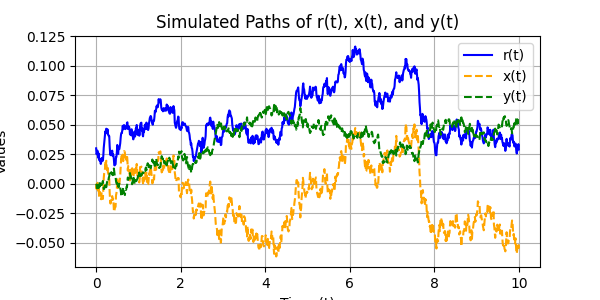

In [154]:
## plot results

t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, 2)

plt.figure(figsize=(6, 3)) 
plt.plot(t, r[:,0], label='r(t)', color='blue')
plt.plot(t, x[:,0], label='x(t)', color='orange', linestyle='--')
plt.plot(t, y[:,0], label='y(t)', color='green', linestyle='--')
plt.title('Simulated Paths of r(t), x(t), and y(t)')    
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.show()

---
# 2. Zero Coupon Bond


### (a) Closed Form Zero Coupon Bond Price Formula

The value at time $t$ of a zero-coupon bond maturing at T with unit face value is
$$
P(t,T) = \mathbb{E^Q}[e^{-\int_t^T r(s) ds} \mid \mathcal{F}_t]
$$
Lemma (proof in Brigo Mercurio):
$$
\int_t^T [x(u) + y(u)] du \sim \mathcal{N}(M(t,T),V(t,T))
$$
Which implies (MGF of Gaussian, and $\varphi (u)$ is deterministic)
$$
P(t,T) = \exp\left\{-\int_t^T \varphi (u) du - M(t,T) + \frac{1}{2} V(t,T)\right\}
$$
where
$$
\exp\left\{-\int_t^T \varphi (u) du\right\} = \frac{P^M(0,T) \exp\left\{-\frac{1}{2} V(0,T)\right\}}{P^M(0,t) \exp\left\{-\frac{1}{2} V(0,t)\right\}}
$$
with $M(t,T)$ and $V(t,T)$ deterministic functions of the parameters $a$, $b$, $\sigma$, $\eta$, $\rho$, $x(t)$, $y(t)$ 

<br>

*Sketch proof:*

Market price must match model price, and $M(0,T) = 0$

So,
$$
P^M(0,T) = \exp\left\{-\int_0^T \varphi (u) du\right\}\exp\left\{-\frac{1}{2} V(0,T)\right\}
$$

*Note : only integral of $\varphi (t)$ is needed for zero coupon bond prices, but we can derive the full $\varphi (t)$ function using the forward rate and a more complicated formula. But, this will likely lead to approximation error from interpolation and differenciation in the yield curve*

### (b) Get Bond Yield Surface

To simulate the whole yield curve, only need to simulate x(t) and y(t) and the yield curve at anytime t is determined analytically by the zero coupon bond price formula

In [155]:
## Function to get bond price from x(t) and y(t)

def BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t):
    def M(t, T, a, b, x_t, y_t):
        return ((1 - np.exp(-a*(T-t)))/a)*x_t + ((1 - np.exp(-b*(T-t)))/b)*y_t
    def V(t, T, a, b, sigma, eta, rho):
        term1 = (sigma**2 / a**2) * (T - t + (2/a)*np.exp(-a*(T-t)) - (1/(2*a))*np.exp(-2*a*(T-t)) - (3/(2*a)))
        term2 = (eta**2 / b**2) * (T - t + (2/b)*np.exp(-b*(T-t)) - (1/(2*b))*np.exp(-2*b*(T-t)) - (3/(2*b)))
        term3 = (2*rho*sigma*eta/(a*b)) * (T - t + (np.exp(-a*(T-t))-1)/a + (np.exp(-b*(T-t))-1)/b - (np.exp(-(a+b)*(T-t))-1)/(a+b))
        return term1 + term2 + term3
    global phi
    int_phi = phi(t)*(T-t)    # defined as a constant for simplicity, to be adjusted
    BondPrice = np.exp(-int_phi - M(t, T, a, b, x_t, y_t) + 0.5*V(t, T, a, b, sigma, eta, rho))

    return BondPrice

def BondYield(t, T, a, b, sigma, eta, rho, x_t, y_t):
    BondYield = -np.log(BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t)) / (T - t)
    return  BondYield


In [156]:
## Simulation of yield surface

# simulate paths
t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, 2)

# times and tenors
tenors = np.array([0.1, 0.25, 0.5, 1, 2, 3, 5, 7, 10])   #tenors where bond price will be calculated
t_times = np.arange(0, 12, 2)    #time points where yield curve will be calculated
# t_times = np.array([0,1]) #use for visualization of one yield curve at t=0 and t=1
t_index = np.array([np.argmin(np.abs(t - t_snap)) for t_snap in t_times]) # find closest time simulated versus time point of the curve

# yield surface matrix
yield_curves = np.zeros((len(t_times), len(tenors)))

# loop for each time point and tenor to calculate yield
for i, idx in enumerate(t_index):
    t_i = t[idx]  # current time
    x_i = x[idx, 0]  # x(t_i) for the first path
    y_i = y[idx, 0]  # y(t_i) for the first path
    T_vec = t_i + tenors   #maturity vector for each t_i

    yield_curves[i, :] = BondYield(t_i, T_vec, a, b, sigma, eta, rho, x_i, y_i)  #get yield at each t_i for each tenors

### (c) Plot Results

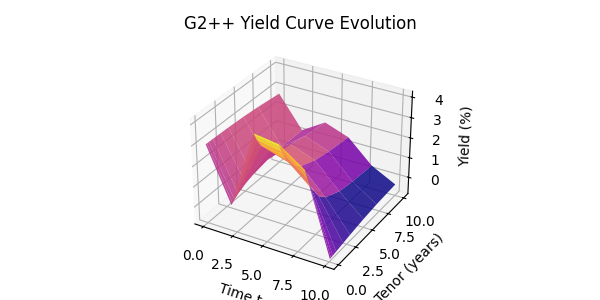

In [157]:
# from mpl_toolkits.mplot3d import Axes3D
# %matplotlib widget

# grid
T_grid, Tenor_grid = np.meshgrid(t_times, tenors, indexing = 'ij')

fig = plt.figure(figsize=(6, 3))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(T_grid, Tenor_grid, yield_curves * 100, cmap='plasma', alpha=0.85)
ax.set_xlabel('Time t')
ax.set_ylabel('Tenor (years)')
ax.set_zlabel('Yield (%)')
ax.set_title('G2++ Yield Curve Evolution')
plt.tight_layout()
plt.show()

<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE: Humped Curve</b> 
</div>

C:\Users\victo\AppData\Local\Temp\ipykernel_18828\4263166471.py:18: RuntimeWarning: invalid value encountered in divide
  BondYield = -np.log(BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t)) / (T - t)


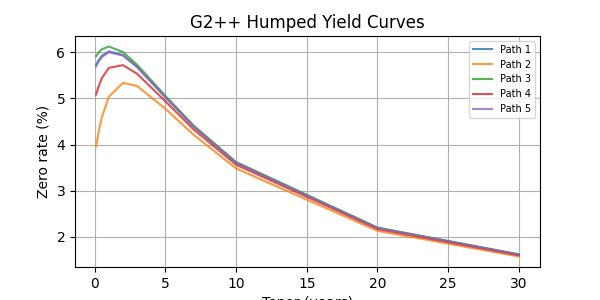

In [158]:
# parameters for humped curves
a     = 1.5    # very fast → x effect vanishes by 1-2 years
b     = 0.25    # moderate → y decays over 5-10 years
sigma = 0.03
eta   = 0.08
rho   = -0.9

def phi(t):
    return 0.05   # 5% base rate

M = 5          #simulate 5 independant paths
tenors   = np.array([0, 0.1, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
t_target = 1  # curve at t=1 for each simulation

# x < 0 and y > 0 → this is what creates the hump
x_vals = np.random.uniform(-0.04, -0.01, M)
y_vals = np.random.uniform(0.02, 0.02, M)

yields_humped = np.zeros((M, len(tenors)))
for m in range(M):
    T_vec = t_target + tenors
    yields_humped[m, :] = BondYield(t_target, T_vec, a, b, sigma, eta, rho, x_vals[m], y_vals[m])

plt.figure(figsize=(6, 3))
for m in range(M):
    plt.plot(tenors, yields_humped[m, :] * 100, alpha=0.8, label=f'Path {m+1}')
plt.xlabel('Tenor (years)')
plt.ylabel('Zero rate (%)')
plt.title('G2++ Humped Yield Curves')
plt.legend(fontsize=7)
plt.grid()
plt.show()



<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE ^</b> 
</div>

---
# 3. Caps & Floors

<div style="background-color: #fff3cd; padding: 10px; border-left: 4px solid #ffc107;">
⚠️ <b>TO DO: Python code to price and calibrate caps/floors</b> 
</div>

### (a) Introduction to Caps / Floors

A caplet / flooret is an interest rate derivative giving its holder the right to pay a predetermined fixed rate at maturity and receiving the floating rate. A cap / floor is a sequence of caplets / floorets. A common strategy using caps and floors is to be long a cap and short a floor (a collar), hence limiting the risk of rates rising above the cap strike, but paying a minimum rate equal to the floor strike if rates fall below it. The premium received from selling the floor offsets the cost of buying the cap, often achieving a near zero-cost hedge.

Some model, including the Gn++ have a closed form formula for the pricing of caplet / flooret, under the $Q^T$ forward measure, making it efficient to calibrate to market data.

### (b) Pricing of Cap & Floor

**T-Forward dynamics** 

First, derive the dynamics of the G2++ model under the T-forward measure.

The Radon-Nikodym derivative is 
$$
\frac{dQ^T}{dQ} = \frac{B(0)P(T,T)}{B(T)P(0,T)} = \cdots = \exp\left\lbrace -\frac{1}{2}V(0,T) - \int_0^T[x(u) + y(u)]\,du \right\rbrace
$$
leading to the following dynamics
$$
dx(t) = \left[-ax(t) - \frac{\sigma^2}{a}(1 - e^{-a(T-t)}) - \rho\frac{\sigma \eta}{b}(1 - e^{-b(T-t)})\right]dt + \sigma dW_1^T(t)
$$
$$
dy(t) = \left[-by(t) - \frac{\eta^2}{b}(1 - e^{-b(T-t)}) - \rho\frac{\sigma \eta}{a}(1 - e^{-a(T-t)})\right]dt + \sigma dW_2^T(t)
$$
Moveover, explicit solutions are
$$
x(t) = x(s)e^{-a(t-s)} - M_x^T(s,t) + \sigma\int_s^t e^{-a(t-u)}dW_1^T(u)
$$
$$
y(t) = y(s)e^{-b(t-s)} - M_y^T(s,t) + \eta\int_s^t e^{-b(t-u)}dW_2^T(u)
$$
with deterministic functions $M_x^T(s,t)$ and $M_y^T(s,t)$

So that under $Q^T$, $r(t)$ conditional on $\mathcal{F}_s$ is normal with mean and variance given by
$$
{E^Q}^T\left[r(t) \mid \mathcal{F}_s\right] = 
x(s)e^{-a(t-s)} - M_x^T(s,t) + y(s)e^{-b(t-s)} - M_y^T(s,t)
$$
$$
Var^{Q^T}\left[r(t) \mid \mathcal{F}_s\right] = 
\frac{\sigma^2}{2a}\left[1 - e^{-2a(t-s)}\right] + \frac{\eta^2}{2b}\left[1 - e^{-2b(t-s)}\right] + \rho \frac{\sigma \eta}{a+b}\left[1 - e^{-(a+b)(t-s)}\right]
$$


**European zero coupon bond options**

The payoff of a European call option with maturity T and strike K on a zero coupon bond with unit face value at maturity S is given by
$$
ZBC(t,T_n,T_N,K) = P(t,T_n){E^Q}^T\left[{(P(T_n,T_N) - K)}^+ \mid \mathcal{F}_t\right]
$$
Since the dynamic of r(t) is Gaussian under the T-forward measure $Q^T$, so the bond price is lognormally distributed.

Thus, with Black's formula, we get the following European call option price
$$
\small
\begin{aligned}
ZBC_t(V,T_n,T_N,K) &= V\,P(t,T_N) \Phi \left(\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} + \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\\\\&
- K\,P(t,T_n) \Phi \left(\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} - \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\end{aligned}
$$

And a European put option price is 
$$
\small
\begin{aligned}
ZBP_t(V,T_n,T_N,K) &= K\,P(t,T_n) \Phi \left(-\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} + \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\\\\&
- V\,P(t,T_N) \Phi \left(-\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} - \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\end{aligned}
$$


**Caplets and Floorets**

In a short rate model, the simply-compounded rate for $[T_n, T_N]$ is:

$$L(T_n, T_N) = \frac{1}{\tau}\left(\frac{1}{P(T_n, T_N)} - 1\right)$$

The caplet pays when $L > K$, which is equivalent to $P(T_n, T_N) < K^*$ where $K^* = \frac{1}{1+\tau K}$. So the caplet is directly a put on the bond price:

$$\text{Caplet}_t(T_n, T_N, V, K) = V(1+\tau K)\cdot ZBP_t(1,\ T_n,\ T_N,\ K^*)$$

Similarly,

$$\text{Flooret}_t(T_n, T_N, V, K) = V(1+\tau K)\cdot ZBC_t(1,\ T_n,\ T_N,\ K^*)$$


The bond prices $P(t,T_n)$ and $P(t,T_N)$ are the G2++ closed-form bond prices, so the caplet is entirely expressed as a function of the short rate factors $x(t)$ and $y(t)$

Now, price caplet and flooret. A caplet is basically having the option to sell a bond (invest selling at strike to receive floating, pay fixed rate to broker) : fixed rate is lower than floating.

For example, at the cap expiry, you have to option to exercice and pay K for your next 3 months rate, or don't exercice and pay floating for your 3 months rate (exercice if strike K < Floating)



**Pricing of cap & floor**

A cap (floor) is a serie of independant caplets (floorets), so

$$\text{Cap}_t(T_0, T_k, V, K) = \sum_{i=1}^k \text{Caplet}_t(T_{i-1},\ T_i,\ V,\ K)$$

where caplet $i$ resets at $T_{i-1}$ and pays at $T_i$

Similarly, 

$$\text{Floor}_t(T_0, T_k, V, K) = \sum_{i=1}^k \text{Flooret}_t(T_{i-1},\ T_i,\ V,\ K)$$




### (c) Montecarlo simulation of caps and floors

In [159]:
# Cap parameters
T_start = 1.0      # start of cap
T_end = 6          # end of cap (1Y into 5Y swaption)
freq  = 0.5        # semi-annual payments
K = 0.06           # cap strike
tenor = freq       # underlying rate tenor
M = 10000          #number of simulated paths for MonteCarlo

pay_dates = np.arange(T_start + freq, T_end + freq/2, freq)
delta = np.full(len(pay_dates), freq)  # year fraction for each payment
# strike (ATM forward swap rate at t=0)
P_ann_0 = sum(d * BondPrice(0, T_j, a, b, sigma, eta, rho, 0.0, 0.0)
              for d, T_j in zip(delta, pay_dates))
P_start_0 = BondPrice(0, T_start, a, b, sigma, eta, rho, 0.0, 0.0)
P_end_0   = BondPrice(0, T_end, a, b, sigma, eta, rho, 0.0, 0.0)

K_atm = (P_start_0 - P_end_0) / P_ann_0


In [160]:
def MC_capfloor(a=a, sigma=sigma, b=b, eta=eta, rho=rho, T=T, N=N, M=M,
                T_start=T_start, T_end=T_end, K=K, tenor=tenor, cap=True):

    t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M)

    expiries    = np.arange(T_start, T_end, freq)          # T_end is last payment
    delta       = np.full(len(expiries), tenor)
    exp_idx     = np.argmin(np.abs(t[:, None] - expiries), axis=0)
    tenor_steps = round(tenor / (t[1] - t[0]))             # steps from expiry to payment date

    x_exp = x[exp_idx, :]
    y_exp = y[exp_idx, :]

    def caplet_price(x_i, y_i, t_i, idx_i, delta_i):
        P_i = BondPrice(t_i, t_i + tenor, a, b, sigma, eta, rho, x_i, y_i)
        L   = (1 / P_i - 1) / delta_i                     # simply compounded rate
        
        if cap:
            payoff = delta_i * np.maximum(L - K, 0)
        else:
            payoff = delta_i * np.maximum(K - L, 0)

        pay_idx  = idx_i + tenor_steps                     # discount to payment date T_N
        int_r    = np.trapezoid(r[:pay_idx+1, :], t[:pay_idx+1], axis=0)
        discount = np.exp(-int_r)

        return np.mean(payoff * discount)

    return sum(
        caplet_price(x_exp[i], y_exp[i], expiries[i], exp_idx[i], delta[i])
        for i in range(len(expiries))
    )


### (d) Analytical price of caps and floors

In [161]:
# from scipy.stats import norm

def Analytical_CapFloor(T_start=T_start, T_end=T_end, N=1, K=K, freq=freq, 
                        cap=True, a=a, b=b, sigma=sigma, eta=eta, rho=rho):

    k     = round((T_end - T_start) / freq)
    delta = (T_end - T_start) / k

    P = lambda T_mat: BondPrice(0, T_mat, a, b, sigma, eta, rho, 0.0, 0.0)

    def Vol2(T_n, T_N):
        term1 = (sigma**2 / (2*a**3)) * (1 - np.exp(-a*(T_N-T_n)))**2 * (1 - np.exp(-2*a*T_n))
        term2 = (eta**2   / (2*b**3)) * (1 - np.exp(-b*(T_N-T_n)))**2 * (1 - np.exp(-2*b*T_n))
        term3 = 2*rho*(sigma*eta / (a*b*(a+b))) * (1 - np.exp(-a*(T_N-T_n))) \
                                                 * (1 - np.exp(-b*(T_N-T_n))) \
                                                 * (1 - np.exp(-(a+b)*T_n))
        return term1 + term2 + term3

    def caplet_flooret(T_n, T_N):
        K_star = 1 / (1 + delta * K)
        Vol    = np.sqrt(Vol2(T_n, T_N))
        d1 = np.log(P(T_N) / (K_star * P(T_n))) / Vol + 0.5 * Vol
        d2 = d1 - Vol
        if cap:
            return N * (P(T_n)*norm.cdf(-d2) - (1 + delta*K)*P(T_N)*norm.cdf(-d1))
        else:
            return N * ((1 + delta*K)*P(T_N)*norm.cdf(d1) - P(T_n)*norm.cdf(d2))

    return sum(caplet_flooret(T_start + i*delta, T_start + (i+1)*delta) for i in range(k))


In [172]:
print(f"The following cap/floor prices are calculated with a strike of {K:.2%}, \nsemi-annual payments starting in {T_start} years and ending in {T_end - T_start} years"
      f"\n(Number of simulated paths for MonteCarlo is {M}, initial curves is at {phi(0):.2%}):")
print(f"\nCap:   MonteCarlo:    {MC_capfloor():.6f}")
print(f"       Analytical:    {Analytical_CapFloor():.6f}")

print(f"Floor: MonteCarlo:    {MC_capfloor(cap=False):.6f}")
print(f"       Analytical:    {Analytical_CapFloor(cap=False):.6f}")

print(f"\nWith the same parameters, the forward-ATM strike K = {K_atm:.2%}, the cap/floor prices are:")
print(f"\nCap:   MonteCarlo:    {MC_capfloor(K=K_atm):.6f}")
print(f"       Analytical:    {Analytical_CapFloor(K=K_atm):.6f}")

print(f"Floor: MonteCarlo:    {MC_capfloor(cap=False, K=K_atm):.6f}")
print(f"       Analytical:    {Analytical_CapFloor(cap=False, K=K_atm):.6f}")

The following cap/floor prices are calculated with a strike of 5.00%, 
semi-annual payments starting in 1.0 years and ending in 5.0 years
(Number of simulated paths for MonteCarlo is 10000, initial curves is at 5.00%):

Cap:   MonteCarlo:    0.100049
       Analytical:    0.099402
Floor: MonteCarlo:    0.199655
       Analytical:    0.199362

With the same parameters, the forward-ATM strike K = 3.66%, the cap/floor prices are:

Cap:   MonteCarlo:    0.143237
       Analytical:    0.143507
Floor: MonteCarlo:    0.142408
       Analytical:    0.143507


---
# 4. Swaptions (Pricing and Calibration)

### (a) Introduction to Swaptions

Swaptions are financial contract where the holder has the option at maturity to enter a swap contract at predetermined rate and maturity. A payer swaption gives the holder the right at maturity to enter a swap contract paying a fixed rate and receiving the floating rate, while a receiver swaption holder has the right to pay the floating rate and receiving a fixed rate, both for a predetermined period (underlying swap maturity).

Swaptions are among the most liquid interest rate derivatives. The price of a swaption is highly affected by the underlying volatility, hence it is important for a model to be able to fit swaptions well.

In most models, swaptions don't have a closed form formula, since the underlying asset is a fixed sequence of bonds, contrary to caps / floors, which are sequence of independant bonds.

Their are two main approaches for the pricing of swaptions. Either price under the forward measure or the forward swap rate measure. The forward measure approach will be introduces briefly, then we will move on to the forward swap rate measure.

### (b) Pricing Swaptions Under the Forward Measure $Q^T$

Recall the dynamics and explicit solution of the short rate $r(t)$ (from $x(t)$, $y(t)$) under the T-forward dynamics $Q^T$

<div style="background-color: #fff3cd; padding: 10px; border-left: 4px solid #ffc107;">
⚠️ <b>TO DO:</b> 
</div>

### (c) Pricing Swaptions Under the Forward Swap Measure $Q^{n+1,N}$

A swaption can be viewed as an option on the swap rate, instead of an option on a serie of bonds. On the latter, we can obtain similar feature as of caplet pricing if we can represents the dynamics of the swap rate under the forward swap measure in an affine model. Schrager and Pelsser proposed an approximation to get an affine term structure model, and hence pricing the swaptions in a similar matter to a caplet.

First, define the value of a forward swap, at the current time $t$, paying a fixed rate $K$ from $T_n$ to $T_N$, as follow:
$$
V_{n,N}^{pay}(t) = V_{n,N}^{flo}(t) - V_{n,N}^{fix}(t) = [D(t,T_n) - D(t,T_N)] - K\sum_{i=n+1}^{N} \Delta_{i-1}^Y D(t, T_i)
$$
where $D(t,T)$ is the bond price from $t$ to $T$, and $\Delta_{i-1}^Y$ is is the market convention for the calculation of the daycount fraction for the
swap payment at $T_i$. Denote $P_{n+1,N}(t) := \sum_{i=n+1}^{N} \Delta_{i-1}^Y D(t, T_i)$, the present value of a basis point (PVBP).

Then, the forward swap rate is
$$
y_{n,N}(t) = \frac{D(t,T_n) - D(t,T_N)}{P_{n+1,N}(t)}
$$
A payer swaption payoff is
$$
[V_{n,N}^{pay}(t)]^+ = P_{n+1,N}(T_n) \, [y_{n,N}(T_n) - K]^+
$$
At time $t$, thevalue of the payer swaption is
$$
PS_t(K) = E^Q \left[\frac{B(t)}{B(T_n)} P_{n+1,N}(T_n) \, [y_{n,N}(T_n) - K]^+ \mid \mathcal{F}_t \right]
$$
Where $B(t) = e^{\int_0^t r_sds}$ is the money market account

Under the forward swap measure $Q^{n+1,N}$
$$
PS_t(K) = P_{n+1,N}(t) \, E^Q \left[ [y_{n,N}(T_n) - K]^+  \mid \mathcal{F}_t \right]
$$

By the Radon-Nikodym derivative $\frac{dQ^{n+1,N}}{dQ} = \frac{P_{n+1,N}(T_n)/P_{n+1,N}(t)}{B(T_n)/B(t)}$

Now for the forward swap rate, under the forward swap measure $Q^{n+1,N}$
$$
dy_{n,N}(t) = \sigma \frac{\partial y_{n,N}(t)}{\partial r(t)} dW_t^{Q^{n+1,N}}
$$

**Schrager and Pelsser** freeze the stochastic bond prices $D^P(t, T_i)$ and swap rate $y_{n,N}(t)$ in the sensitivity $\frac{\partial y_{n,N}(t)}{\partial r(t)}$ at their initial values $D^P(0, T_i)$ and $y_{n,N}(0)$. This makes the diffusion coefficient deterministic, so the forward swap rate becomes normally distributed under the annuity measure, and Bachelier pricing applies.

Note, by Jensen's inequality ($\small E[X^2] \geq E[X]^2$), this approximation will underestimate the variance. This is not critical near ATM strikes, but can lead to larger errors for deep OTM or ITM options.


**For the G2++ model:**

$$
S_0(ATM) \simeq \frac{VOL}{\sqrt{2\pi}}P_{n+1,N}(0)
$$
where, for constant $\sigma$, $\eta$,
$$
VOL^2 = \sigma^2 A^2 \frac{e^{2aT_n} - 1}{2a} + \eta^2 B^2 \frac{e^{2bT_n} - 1}{2b} + 2 \sigma \eta \rho A B \frac{e^{(a+b)T_n} - 1}{a+b}
$$
with
$$
\small
A = \frac{1}{a} \left[e^{-aT_n}\frac{P(0,T_n)}{P_{n+1,N}(0)} - e^{-aT_N}\frac{P(0,T_N)}{P_{n+1,N}(0)} - K\sum_{j=n+1}^N e^{-aT_j}\tau_j\frac{P(0,T_j)}{P_{n+1,N}(0)}\right]
$$
and
$$
\small
B = \frac{1}{b} \left[e^{-bT_n}\frac{P(0,T_n)}{P_{n+1,N}(0)} - e^{-bT_N}\frac{P(0,T_N)}{P_{n+1,N}(0)} - K\sum_{j=n+1}^N e^{-bT_j}\tau_j\frac{P(0,T_j)}{P_{n+1,N}(0)} \right]
$$

<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE :</b> 
</div>

_____

**For the Vasicek model:**

Now for the forward swap rate, under the forward swap measure $Q^{n+1,N}$
$$
dy_{n,N}(t) = \sigma \frac{\partial y_{n,N}(t)}{\partial r(t)} dW_t^{Q^{n+1,N}}
$$
where 
$$
\begin{aligned}
\frac{\partial y_{n,N}(t)}{\partial r(t)} &= -B(t,T_n)D^P(t,T_n) + B(t,T_N)D^P(t,T_N)
\\\\&
+ y_{n,N}(t) \sum_{i=n+1}^{N} \Delta_{i-1}^Y B(t, T_i) D^P(t, T_i)
\end{aligned}
$$
where $D^P(t,T_n) = D(t,T_n)/P_{n+1,N}(t)$, the bond price normalized by the numéraire

**Schrager Pelsser approximation:**

Approximate $D^P(t, T_n)$ by its conditional expectation under the forward swap measure, $D^P(0, T_n)$

Approximate the swap rate itself in the volatility by its martingale value.

That is, $\frac{\partial y_{n,N}(t)}{\partial r(t)} \approx \widetilde{\frac{\partial y_{n,N}(t)}{\partial r(t)}}$ where

$$
\begin{aligned}
\widetilde{\frac{\partial y_{n,N}(t)}{\partial r(t)}} &= -B(t,T_n)D^P(0,T_n) + B(t,T_N)D^P(0,T_N)
\\\\&
+ y_{n,N}(0) \sum_{i=n+1}^{N} \Delta_{i-1}^Y B(t, T_i) D^P(0, T_i)
\end{aligned}
$$
Note, $B(t, T) = \frac{1}{a} - \frac{e^{-aT}}{a} e^{at}$

<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE ^</b> 
</div>

### (d) Montecarlo simulation of swaption price

Now, simulate swaption prices using MonteCarlo, and compare with analytical approximation

In [167]:
# Swaption parameters
T_exp = 1.0        # option expiry
T_end = 6.0        # swap end (1Y into 5Y swaption)
freq  = 0.5        # semi-annual payments
M = 10000          #number of simulated paths for MonteCarlo
K = 0.05           # swaption strike

pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
delta = np.full(len(pay_dates), freq)  # year fraction for each payment

# strike (ATM forward swap rate at t=0)
P_ann_0 = sum(d * BondPrice(0, T_j, a, b, sigma, eta, rho, 0.0, 0.0)
              for d, T_j in zip(delta, pay_dates))
P_start_0 = BondPrice(0, T_exp, a, b, sigma, eta, rho, 0.0, 0.0)
P_end_0   = BondPrice(0, T_end, a, b, sigma, eta, rho, 0.0, 0.0)

K_atm = (P_start_0 - P_end_0) / P_ann_0

In [168]:
def MC_swaption(a=a, sigma=sigma, b=b, eta=eta, rho=rho, T=T, N=N, M=M, 
                T_exp=T_exp, T_end=T_end, K=K):

    pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
    delta     = np.full(len(pay_dates), freq)

    # Simulate paths
    t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M)

    exp_idx = np.argmin(np.abs(t - T_exp))  # index for swaption expiry
    x_exp = x[exp_idx, :]     #shape is (M,)
    y_exp = y[exp_idx, :]

    # Compute payoff at expiry

    annuity = sum(d * BondPrice(T_exp, T_j, a, b, sigma, eta, rho, x_exp, y_exp) 
                for d, T_j in zip(delta, pay_dates))
    P_end = BondPrice(T_exp, T_end, a, b, sigma, eta, rho, x_exp, y_exp) #5Y bond price at expiry

    Swap_exp = (1 - P_end) / annuity
    payoff = np.maximum(Swap_exp - K, 0) * annuity #payoff at expiry, payer swaption


    # Discount payoff back to time 0
    int_r    = np.trapezoid(r[:exp_idx+1, :], t[:exp_idx+1], axis=0)
    discount = np.exp(-int_r)

    price = np.mean(discount * payoff)
    return price

### (e) Schrager-Pelsser swaption price approximation

In [169]:
def swaption_analytical(T_exp=T_exp, T_end=T_end, K=K, freq=freq, 
                        a=a, b=b, sigma=sigma, eta=eta, rho=rho):

    pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
    delta     = np.full(len(pay_dates), freq)

    # Bond prices at t=0 (x=0, y=0)
    P = lambda T_mat: BondPrice(0, T_mat, a, b, sigma, eta, rho, 0.0, 0.0)  # noqa: E731

    # Annuity at t=0
    P_ann = sum(d * P(T_j) for d, T_j in zip(delta, pay_dates))

    # A coefficients (eq 3.28, Difra)
    def A(ai):
        term1 = (1/ai) * np.exp(-ai * T_exp) * P(T_exp) / P_ann
        term2 = (1/ai) * np.exp(-ai * T_end) * P(T_end) / P_ann
        term3 = (K/ai) * sum(d * np.exp(-ai * T_j) * P(T_j) / P_ann
                             for d, T_j in zip(delta, pay_dates))
        return term1 - term2 - term3

    A, B = A(a), A(b)

    # Integrated variance (eq 3.29)
    VOL2 = (sigma**2 * A**2 * (np.exp(2*a*T_exp) - 1) / (2*a)
          + eta**2   * B**2 * (np.exp(2*b*T_exp) - 1) / (2*b)
          + 2*rho*sigma*eta * A*B * (np.exp((a+b)*T_exp) - 1) / (a+b))

    # Bachelier ATM price (eq 3.26)
    return P_ann * np.sqrt(max(VOL2, 0)) / np.sqrt(2 * np.pi)


In [171]:
print(f"The following swaption prices are calculated with a ATM strike of {K:.2%}, \nsemi-annual payments, option expiry in {T_start} years with a underlying swap tenor of of {T_end - T_start} years"
      f"\n(Number of simulated paths for MonteCarlo is {M}, initial curves is at {phi(0):.2%}):")

print(f"\nMontecarlo simulation:        {MC_swaption(K=K_atm):.6f}")
print(f"Schrager-Pelsser analytical approx.: {swaption_analytical(K=K_atm):.6f}")

print(f"\nWith the same parateters, but a OTM strike at {K:.2%}:")
print(f"\nMontecarlo simulation:        {MC_swaption(K=K):.6f}")
print(f"Schrager-Pelsser analytical approx.: {swaption_analytical(K=K):.6f}")

The following swaption prices are calculated with a ATM strike of 5.00%, 
semi-annual payments, option expiry in 1.0 years with a underlying swap tenor of of 5.0 years
(Number of simulated paths for MonteCarlo is 10000, initial curves is at 5.00%):

Montecarlo simulation:        0.068714
Schrager-Pelsser analytical approx.: 0.068778

With the same parateters, but a OTM strike at 5.00%:

Montecarlo simulation:        0.042896
Schrager-Pelsser analytical approx.: 0.065265


---
# 5. Binomial Tree

<div style="background-color: #fff3cd; padding: 10px; border-left: 4px solid #ffc107;">
⚠️ <b>TO DO:</b> 
</div>

Objective of this section is to create a tree to price american style derivatives (early exercices options)

### (a) Introduction to pricing trees